Name: James Fisher
Date: April 17, 2026
Course: DDS-8555 (Predictive Analytics)
Assignment: Week 8, San Francisco Crim Classification (2 tree models & 1 SVM)

In [ ]:
# Load libraries
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

# Load data
train = pd.read_csv("data/crime/train.csv")
test = pd.read_csv("data/crime/test.csv")
sample_submission = pd.read_csv("data/crime/sampleSubmission.csv")

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Sample submission shape:', sample_submission.shape)

train.head()


Train shape: (878049, 9)
Test shape: (884262, 7)
Sample submission shape: (884262, 40)


,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541


In [9]:
# Check columns and number of classes
print(train.columns.tolist())
print(test.columns.tolist())
print(sample_submission.columns.tolist()[:10], '...')
print('Number of classes in sample submission:', len(sample_submission.columns) - 1)

['Dates', 'Category', 'Descript', 'DayOfWeek', 'PdDistrict', 'Resolution', 'Address', 'X', 'Y']
['Id', 'Dates', 'DayOfWeek', 'PdDistrict', 'Address', 'X', 'Y']
['Id', 'ARSON', 'ASSAULT', 'BAD CHECKS', 'BRIBERY', 'BURGLARY', 'DISORDERLY CONDUCT', 'DRIVING UNDER THE INFLUENCE', 'DRUG/NARCOTIC', 'DRUNKENNESS'] ...
Number of classes in sample submission: 39


In [10]:
# Check target distribution and missing values
print(train['Category'].value_counts().head(10))
print('Missing values in train:')
print(train.isna().sum())
print('Missing values in test:')
print(test.isna().sum())

Category
LARCENY/THEFT     174900
OTHER OFFENSES    126182
NON-CRIMINAL       92304
ASSAULT            76876
DRUG/NARCOTIC      53971
VEHICLE THEFT      53781
VANDALISM          44725
WARRANTS           42214
BURGLARY           36755
SUSPICIOUS OCC     31414
Name: count, dtype: int64
Missing values in train:
Dates         0
Category      0
Descript      0
DayOfWeek     0
PdDistrict    0
Resolution    0
Address       0
X             0
Y             0
dtype: int64
Missing values in test:
Id            0
Dates         0
DayOfWeek     0
PdDistrict    0
Address       0
X             0
Y             0
dtype: int64


In [11]:
# Create feature engineering pipeline
def add_features(df):
    df = df.copy()

    dt = pd.to_datetime(df['Dates'])
    df['Year'] = dt.dt.year
    df['Month'] = dt.dt.month
    df['Day'] = dt.dt.day
    df['Hour'] = dt.dt.hour
    df['Minute'] = dt.dt.minute
    df['IsWeekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday']).astype(int)
    df['IsNight'] = ((df['Hour'] >= 20) | (df['Hour'] <= 5)).astype(int)
    df['IsBusinessHour'] = ((df['Hour'] >= 8) & (df['Hour'] <= 17)).astype(int)

    df['AddressHasSlash'] = df['Address'].str.contains('/', regex=False).astype(int)
    df['AddressHasBlock'] = df['Address'].str.contains('BLOCK', case=False, na=False).astype(int)
    df['AddressLength'] = df['Address'].fillna('').str.len()

    # Rounded spatial buckets for additional location signal
    df['X_round2'] = df['X'].round(2)
    df['Y_round2'] = df['Y'].round(2)

    # Mild nonlinear spatial terms for the SVM and tree models
    df['X2'] = df['X'] ** 2
    df['Y2'] = df['Y'] ** 2
    df['XY'] = df['X'] * df['Y']

    return df

# Apply feature engineering
train_fe = add_features(train)
test_fe = add_features(test)

train_fe.head()

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y,Year,Month,Day,Hour,Minute,IsWeekend,IsNight,IsBusinessHour,AddressHasSlash,AddressHasBlock,AddressLength,X_round2,Y_round2,X2,Y2,XY
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,2015,5,13,23,53,0,1,0,1,0,18,-122.43,37.77,14988.098952,1426.920299,-4624.588916
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,2015,5,13,23,53,0,1,0,1,0,18,-122.43,37.77,14988.098952,1426.920299,-4624.588916
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414,2015,5,13,23,33,0,1,0,1,0,25,-122.42,37.80,14987.724661,1428.871323,-4627.691645
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873,2015,5,13,23,30,0,1,0,0,1,24,-122.43,37.80,14988.369185,1428.905972,-4627.847257
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541,2015,5,13,23,30,0,1,0,0,1,25,-122.44,37.77,14991.244471,1426.689323,-4624.699819


In [12]:
# Prepare data for modeling
TARGET = 'Category'
ID_COL = 'Id'
DROP_COLUMNS = ['Dates', 'Descript', 'Resolution']

# Select features and target
feature_columns = [c for c in train_fe.columns if c not in [TARGET] + DROP_COLUMNS]
X = train_fe[feature_columns].copy()
y = train_fe[TARGET].copy()
X_test = test_fe[[c for c in feature_columns if c in test_fe.columns]].copy()

# Ensure column order matches
X_test = X_test[X.columns.tolist()]

# Check final feature and row counts
print('Feature count:', X.shape[1])
print('Training rows:', X.shape[0])
print('Test rows:', X_test.shape[0])

Feature count: 21
Training rows: 878049
Test rows: 884262


In [13]:
# Identify categorical and numeric features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

# Print feature type counts
print('Categorical features:', categorical_features)
print('Numeric feature count:', len(numeric_features))

Categorical features: ['DayOfWeek', 'PdDistrict', 'Address']
Numeric feature count: 18


In [14]:
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

# Check training and validation shapes
print(X_train.shape, X_valid.shape)
print(y_train.shape, y_valid.shape)

(702439, 21) (175610, 21)
(702439,) (175610,)


In [25]:
# Manage SVM Settings (keep runtime reasonable for my computer)

# Implement protection for rare classes in SVM sampling
def make_svm_sample_with_rare_class_protection(X_df, y_series, target_n, min_keep_per_class=2, rare_threshold=10, random_state=42):
    # If target_n is larger than the dataset, just return the whole thing
    if target_n >= len(X_df):
        return X_df.copy(), y_series.copy()
    
    # Identify rare classes based on the threshold
    counts = y_series.value_counts()

    # Rare classes: keep all rows
    rare_classes = counts[counts <= rare_threshold].index
    rare_mask = y_series.isin(rare_classes)

    X_rare = X_df.loc[rare_mask]
    y_rare = y_series.loc[rare_mask]

    X_common = X_df.loc[~rare_mask]
    y_common = y_series.loc[~rare_mask]

    # Calculate how many more rows can be taken from common classes
    remaining_n = target_n - len(X_rare)

    # If rare classes alone exceed target_n, keep them anyway
    if remaining_n <= 0:
        # If rare classes alone exceed target_n, keep them anyway
        # because preserving class support matters more here than exact size
        out_X = X_rare.copy()
        out_y = y_rare.copy()
    else:
        # Take stratified sample from common classes to fill up to target_n total rows
        X_common_sample, _, y_common_sample, _ = train_test_split(
            X_common,
            y_common,
            train_size=remaining_n,
            stratify=y_common,
            random_state=random_state
        )

        out_X = pd.concat([X_rare, X_common_sample], axis=0)
        out_y = pd.concat([y_rare, y_common_sample], axis=0)

    # Shuffle final sample
    shuffled_idx = out_y.sample(frac=1.0, random_state=random_state).index
    out_X = out_X.loc[shuffled_idx]
    out_y = out_y.loc[shuffled_idx]

    # Verify that this worked as intended
    min_count = out_y.value_counts().min()
    if min_count < min_keep_per_class:
        bad = out_y.value_counts()[out_y.value_counts() < min_keep_per_class]
        raise ValueError(
            f"SVM sample still has classes with fewer than {min_keep_per_class} examples:\n{bad}"
        )

    return out_X, out_y


# Downsample in a stratified way to maintain class balance
SVM_VALIDATION_SAMPLE_N = 120_000
SVM_FULLTRAIN_SAMPLE_N = 160_000

X_train_svm, y_train_svm = make_svm_sample_with_rare_class_protection(
    X_train, y_train,
    target_n=SVM_VALIDATION_SAMPLE_N,
    min_keep_per_class=2,
    rare_threshold=10,
    random_state=42
)

X_svm_full, y_svm_full = make_svm_sample_with_rare_class_protection(
    X, y,
    target_n=SVM_FULLTRAIN_SAMPLE_N,
    min_keep_per_class=2,
    rare_threshold=10,
    random_state=42
)

# Check class counts and shapes to confirm sampling worked
print("Minimum class count in original training split:", y_train.value_counts().min())
print("Minimum class count in SVM validation sample:", y_train_svm.value_counts().min())
print("Minimum class count in full data:", y.value_counts().min())
print("Minimum class count in SVM full-training sample:", y_svm_full.value_counts().min())

# Check shapes
print("SVM validation-train sample shape:", X_train_svm.shape)
print("SVM full-train sample shape:", X_svm_full.shape)

Minimum class count in original training split: 5
Minimum class count in SVM validation sample: 3
Minimum class count in full data: 6
Minimum class count in SVM full-training sample: 4
SVM validation-train sample shape: (120000, 21)
SVM full-train sample shape: (160000, 21)


In [26]:
# Build preprocessing pipelines
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_features)
    ]
)

svm_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)

In [27]:
# Define models as pipelines with preprocessing
models = {
    'decision_tree': Pipeline([
        ('prep', tree_preprocessor),
        ('model', DecisionTreeClassifier(
            criterion='gini',
            max_depth=25,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=123
        ))
    ]),
    'random_forest': Pipeline([
        ('prep', tree_preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=250,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=3,
            max_features='sqrt',
            n_jobs=-1,
            random_state=123,
            verbose=0
        ))
    ]),
    'svm_calibrated': Pipeline([
        ('prep', svm_preprocessor),
        ('model', CalibratedClassifierCV(
            estimator=LinearSVC(
                C=1.0,
                class_weight='balanced',
                dual='auto',
                random_state=123,
                max_iter=3000
            ),
            method='sigmoid',
            cv=2
        ))
    ])
}

list(models.keys())

['decision_tree', 'random_forest', 'svm_calibrated']

In [28]:
# Fit and evaluate on validation data
label_order = sample_submission.columns[1:].tolist()

# Store results and trained models
results = []
trained_models = {}

for name, pipe in models.items():
    print(f'Fitting {name}...')

    if name == 'svm_calibrated':
        X_fit, y_fit = X_train_svm, y_train_svm
        print(f'Using stratified sample for SVM: {X_fit.shape[0]:,} rows')
    else:
        X_fit, y_fit = X_train, y_train

    pipe.fit(X_fit, y_fit)
    valid_proba = pipe.predict_proba(X_valid)

    # Align validation probabilities to sample submission column order
    valid_classes = pipe.named_steps['model'].classes_
    proba_df = pd.DataFrame(valid_proba, columns=valid_classes, index=X_valid.index)
    proba_df = proba_df.reindex(columns=label_order, fill_value=1e-15)
    proba_df = proba_df.clip(1e-15, 1 - 1e-15)
    proba_df = proba_df.div(proba_df.sum(axis=1), axis=0)

    ll = log_loss(y_valid, proba_df.values, labels=label_order)
    results.append({'model': name, 'validation_log_loss': ll})
    trained_models[name] = pipe
    print(f'{name} validation log loss: {ll:.6f}')
    print()

# Display results
results_df = pd.DataFrame(results).sort_values('validation_log_loss').reset_index(drop=True)
results_df


Fitting decision_tree...
decision_tree validation log loss: 4.028039

Fitting random_forest...
random_forest validation log loss: 2.385286

Fitting svm_calibrated...
Using stratified sample for SVM: 120,000 rows
svm_calibrated validation log loss: 2.496804



,model,validation_log_loss
0,random_forest,2.385286
1,svm_calibrated,2.496804
2,decision_tree,4.028039


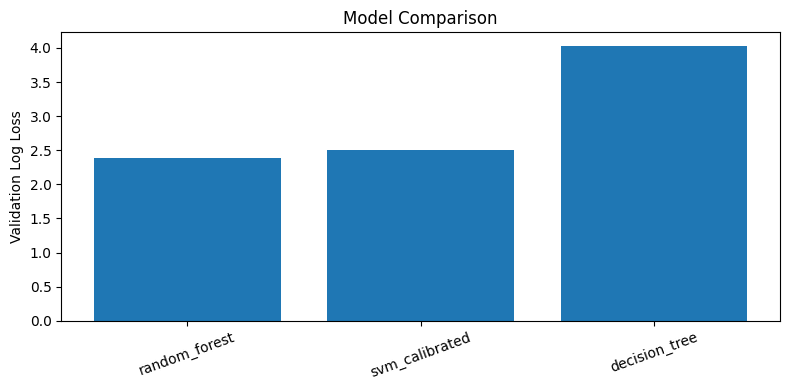

In [29]:
# Visualize validation log loss for each model
plt.figure(figsize=(8, 4))
plt.bar(results_df['model'], results_df['validation_log_loss'])
plt.ylabel('Validation Log Loss')
plt.title('Model Comparison')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [30]:
# Refit best model on full training data
full_trained_models = {}

# Refit each model on the full training data (or SVM sample) for final predictions
for name, pipe in models.items():
    print(f'Refitting {name} on training data...')

    if name == 'svm_calibrated':
        X_fit, y_fit = X_svm_full, y_svm_full
        print(f'Using stratified sample for final SVM fit: {X_fit.shape[0]:,} rows')
    else:
        X_fit, y_fit = X, y

    fitted = clone(pipe)
    fitted.fit(X_fit, y_fit)
    full_trained_models[name] = fitted

Refitting decision_tree on training data...
Refitting random_forest on training data...
Refitting svm_calibrated on training data...
Using stratified sample for final SVM fit: 160,000 rows


In [31]:
# Kaggle submission file creator (proper probabilities using method)
def make_submission(model_name, fitted_model, X_test, sample_submission, out_name):
    test_proba = fitted_model.predict_proba(X_test)
    test_classes = fitted_model.named_steps['model'].classes_

    submission = pd.DataFrame(test_proba, columns=test_classes)
    submission = submission.reindex(columns=sample_submission.columns[1:], fill_value=1e-15)
    submission = submission.clip(1e-15, 1 - 1e-15)
    submission = submission.div(submission.sum(axis=1), axis=0)
    submission.insert(0, 'Id', sample_submission['Id'].values)
    submission.to_csv(out_name, index=False)
    print(f'Saved {out_name}')
    return submission

submission_dt = make_submission(
    'decision_tree',
    full_trained_models['decision_tree'],
    X_test,
    sample_submission,
    'data/outputs/submission_decision_tree.csv'
)

submission_rf = make_submission(
    'random_forest',
    full_trained_models['random_forest'],
    X_test,
    sample_submission,
    'data/outputs/submission_random_forest.csv'
)

submission_svm = make_submission(
    'svm_calibrated',
    full_trained_models['svm_calibrated'],
    X_test,
    sample_submission,
    'data/outputs/submission_svm_calibrated.csv'
)

Saved data/outputs/submission_decision_tree.csv
Saved data/outputs/submission_random_forest.csv
Saved data/outputs/submission_svm_calibrated.csv


In [32]:
# Confirm success
print('Decision Tree submission preview:')
display(submission_dt.head())

print('Random Forest submission preview:')
display(submission_rf.head())

print('SVM submission preview:')
display(submission_svm.head())

Decision Tree submission preview:


,Id,ARSON,ASSAULT,BAD CHECKS,BRIBERY,BURGLARY,DISORDERLY CONDUCT,DRIVING UNDER THE INFLUENCE,DRUG/NARCOTIC,DRUNKENNESS,EMBEZZLEMENT,EXTORTION,FAMILY OFFENSES,FORGERY/COUNTERFEITING,FRAUD,GAMBLING,KIDNAPPING,LARCENY/THEFT,LIQUOR LAWS,LOITERING,MISSING PERSON,NON-CRIMINAL,OTHER OFFENSES,PORNOGRAPHY/OBSCENE MAT,PROSTITUTION,RECOVERED VEHICLE,ROBBERY,RUNAWAY,SECONDARY CODES,SEX OFFENSES FORCIBLE,SEX OFFENSES NON FORCIBLE,STOLEN PROPERTY,SUICIDE,SUSPICIOUS OCC,TREA,TRESPASS,VANDALISM,VEHICLE THEFT,WARRANTS,WEAPON LAWS
0,0,5.237677e-02,0.043326,1.000000e-15,1.163306e-01,0.025350,1.278521e-02,0.014823,0.012147,2.188187e-02,1.441661e-02,1.000000e-15,5.379908e-02,8.148764e-03,0.015118,1.644791e-02,6.052214e-02,0.014609,1.388090e-02,3.920646e-03,0.030954,0.027863,0.019869,1.000000e-15,6.417412e-04,1.000000e-15,0.024327,2.591434e-02,6.228958e-02,2.407963e-02,3.245129e-02,3.649698e-02,2.363578e-02,0.032030,1.000000e-15,2.753443e-02,0.025450,0.020540,0.028216,5.782437e-02
1,1,1.000000e-15,0.027695,1.000000e-15,1.000000e-15,0.005793,1.000000e-15,0.469369,0.039448,1.000000e-15,1.000000e-15,1.000000e-15,1.000000e-15,1.000000e-15,0.038295,1.000000e-15,1.000000e-15,0.080342,1.000000e-15,1.000000e-15,0.024576,0.032292,0.079303,1.000000e-15,1.000000e-15,1.000000e-15,0.055541,1.000000e-15,1.000000e-15,1.000000e-15,1.000000e-15,1.000000e-15,1.000000e-15,0.027110,1.000000e-15,1.000000e-15,0.061884,0.007918,0.050435,1.000000e-15
2,2,4.980305e-02,0.037835,6.291393e-03,3.712139e-02,0.035470,3.293398e-02,0.048203,0.018311,6.964660e-02,7.229166e-03,2.195106e-02,1.612698e-02,1.182170e-02,0.014733,8.747621e-03,3.316996e-02,0.019013,3.691193e-02,9.383163e-03,0.015077,0.025199,0.019316,1.000000e-15,2.822569e-02,2.596633e-02,0.036682,1.010696e-02,3.351167e-02,3.195792e-02,1.208117e-02,4.011497e-02,3.268304e-02,0.026849,1.000000e-15,3.667935e-02,0.036774,0.015991,0.026194,3.188776e-02
3,3,5.237677e-02,0.043326,1.000000e-15,1.163306e-01,0.025350,1.278521e-02,0.014823,0.012147,2.188187e-02,1.441661e-02,1.000000e-15,5.379908e-02,8.148764e-03,0.015118,1.644791e-02,6.052214e-02,0.014609,1.388090e-02,3.920646e-03,0.030954,0.027863,0.019869,1.000000e-15,6.417412e-04,1.000000e-15,0.024327,2.591434e-02,6.228958e-02,2.407963e-02,3.245129e-02,3.649698e-02,2.363578e-02,0.032030,1.000000e-15,2.753443e-02,0.025450,0.020540,0.028216,5.782437e-02
4,4,5.237677e-02,0.043326,1.000000e-15,1.163306e-01,0.025350,1.278521e-02,0.014823,0.012147,2.188187e-02,1.441661e-02,1.000000e-15,5.379908e-02,8.148764e-03,0.015118,1.644791e-02,6.052214e-02,0.014609,1.388090e-02,3.920646e-03,0.030954,0.027863,0.019869,1.000000e-15,6.417412e-04,1.000000e-15,0.024327,2.591434e-02,6.228958e-02,2.407963e-02,3.245129e-02,3.649698e-02,2.363578e-02,0.032030,1.000000e-15,2.753443e-02,0.025450,0.020540,0.028216,5.782437e-02


Random Forest submission preview:


,Id,ARSON,ASSAULT,BAD CHECKS,BRIBERY,BURGLARY,DISORDERLY CONDUCT,DRIVING UNDER THE INFLUENCE,DRUG/NARCOTIC,DRUNKENNESS,EMBEZZLEMENT,EXTORTION,FAMILY OFFENSES,FORGERY/COUNTERFEITING,FRAUD,GAMBLING,KIDNAPPING,LARCENY/THEFT,LIQUOR LAWS,LOITERING,MISSING PERSON,NON-CRIMINAL,OTHER OFFENSES,PORNOGRAPHY/OBSCENE MAT,PROSTITUTION,RECOVERED VEHICLE,ROBBERY,RUNAWAY,SECONDARY CODES,SEX OFFENSES FORCIBLE,SEX OFFENSES NON FORCIBLE,STOLEN PROPERTY,SUICIDE,SUSPICIOUS OCC,TREA,TRESPASS,VANDALISM,VEHICLE THEFT,WARRANTS,WEAPON LAWS
0,0,0.005814,0.135845,0.000110,0.000720,0.036721,0.002881,0.004049,0.036050,0.004107,0.000983,0.000182,0.000713,0.005387,0.008896,0.000137,0.004217,0.117603,0.001501,0.000330,0.059068,0.073666,0.133421,1.373665e-06,0.001378,0.007236,0.036919,0.003591,0.022554,0.005217,0.000237,0.004957,0.000679,0.046526,0.000020,0.005082,0.078465,0.093453,0.040865,0.020417
1,1,0.004194,0.087572,0.000057,0.000352,0.008841,0.001933,0.012619,0.065846,0.004149,0.000210,0.000050,0.000175,0.003719,0.005776,0.000395,0.002284,0.083763,0.001979,0.000823,0.012748,0.048867,0.337024,1.535288e-06,0.002997,0.004338,0.046903,0.000637,0.010967,0.003016,0.000100,0.004868,0.000250,0.036071,0.000018,0.002098,0.039559,0.055620,0.086121,0.023059
2,2,0.002236,0.093550,0.000247,0.000158,0.092671,0.003301,0.003475,0.020429,0.006971,0.001050,0.000173,0.000234,0.008533,0.016726,0.000156,0.002958,0.267609,0.001269,0.000524,0.014260,0.099667,0.089330,5.872921e-06,0.005716,0.002383,0.024727,0.000518,0.014045,0.005613,0.000048,0.007211,0.000495,0.035247,0.000004,0.008689,0.067364,0.068068,0.027792,0.006546
3,3,0.002486,0.188182,0.000090,0.000481,0.033669,0.002893,0.004143,0.035398,0.008479,0.000421,0.000459,0.000610,0.006356,0.010528,0.000173,0.003942,0.101408,0.002274,0.000276,0.029962,0.093723,0.133657,1.000000e-15,0.000353,0.005319,0.040001,0.003040,0.020773,0.006560,0.000157,0.003984,0.002489,0.037987,0.000004,0.003742,0.065479,0.090656,0.041306,0.018539
4,4,0.002486,0.188182,0.000090,0.000481,0.033669,0.002893,0.004143,0.035398,0.008479,0.000421,0.000459,0.000610,0.006356,0.010528,0.000173,0.003942,0.101408,0.002274,0.000276,0.029962,0.093723,0.133657,1.000000e-15,0.000353,0.005319,0.040001,0.003040,0.020773,0.006560,0.000157,0.003984,0.002489,0.037987,0.000004,0.003742,0.065479,0.090656,0.041306,0.018539


SVM submission preview:


,Id,ARSON,ASSAULT,BAD CHECKS,BRIBERY,BURGLARY,DISORDERLY CONDUCT,DRIVING UNDER THE INFLUENCE,DRUG/NARCOTIC,DRUNKENNESS,EMBEZZLEMENT,EXTORTION,FAMILY OFFENSES,FORGERY/COUNTERFEITING,FRAUD,GAMBLING,KIDNAPPING,LARCENY/THEFT,LIQUOR LAWS,LOITERING,MISSING PERSON,NON-CRIMINAL,OTHER OFFENSES,PORNOGRAPHY/OBSCENE MAT,PROSTITUTION,RECOVERED VEHICLE,ROBBERY,RUNAWAY,SECONDARY CODES,SEX OFFENSES FORCIBLE,SEX OFFENSES NON FORCIBLE,STOLEN PROPERTY,SUICIDE,SUSPICIOUS OCC,TREA,TRESPASS,VANDALISM,VEHICLE THEFT,WARRANTS,WEAPON LAWS
0,0,0.002815,0.132559,0.000028,0.000550,0.033708,0.002949,0.006107,0.038454,0.006673,0.000210,0.000288,0.000489,0.003324,0.019007,0.000170,0.003181,0.161930,0.003038,0.000354,0.044463,0.104847,0.136185,0.000008,0.002433,0.005331,0.029698,0.000553,0.012672,0.004941,0.000098,0.006357,0.000554,0.046981,0.000049,0.007028,0.050637,0.070052,0.048315,0.012965
1,1,0.002376,0.116790,0.000032,0.000499,0.030035,0.002655,0.005353,0.060247,0.006225,0.000178,0.000283,0.000336,0.003316,0.012307,0.000169,0.003012,0.157330,0.002598,0.000421,0.013943,0.106520,0.204518,0.000011,0.002996,0.003722,0.032315,0.000484,0.012085,0.004841,0.000097,0.005782,0.000458,0.035788,0.000049,0.005597,0.051821,0.044019,0.059909,0.010885
2,2,0.002084,0.101066,0.000033,0.000419,0.029164,0.002292,0.004468,0.034777,0.005789,0.000207,0.000262,0.000480,0.003259,0.010889,0.000144,0.002677,0.134127,0.002685,0.000355,0.012197,0.081080,0.111889,0.000010,0.002319,0.003764,0.023829,0.000424,0.010810,0.003950,0.000090,0.005496,0.000467,0.031442,0.000039,0.005942,0.060160,0.258835,0.041616,0.010467
3,3,0.002290,0.117968,0.000036,0.000543,0.043015,0.004828,0.013758,0.072596,0.009567,0.000240,0.000298,0.000527,0.005066,0.012866,0.000173,0.003130,0.164224,0.007091,0.000310,0.016714,0.094899,0.148384,0.000013,0.001662,0.003400,0.035232,0.000474,0.013707,0.007232,0.000100,0.005758,0.000497,0.038538,0.000045,0.008227,0.059476,0.037813,0.056573,0.012729
4,4,0.002290,0.117968,0.000036,0.000543,0.043015,0.004828,0.013758,0.072596,0.009567,0.000240,0.000298,0.000527,0.005066,0.012866,0.000173,0.003130,0.164224,0.007091,0.000310,0.016714,0.094899,0.148384,0.000013,0.001662,0.003400,0.035232,0.000474,0.013707,0.007232,0.000100,0.005758,0.000497,0.038538,0.000045,0.008227,0.059476,0.037813,0.056573,0.012729
